# Principal Component Analysis (PCA)
## Dimensionality Reduction on a Benchmark Dataset

This notebook provides a detailed, step-by-step explanation of PCA using the Breast Cancer dataset.

## 1. Import Required Libraries

In [1]:
# Numerical computations
import numpy as np

# Data manipulation
import pandas as pd

# Visualization
import matplotlib.pyplot as plt

# Dataset loader
from sklearn.datasets import load_breast_cancer

# Feature scaling
from sklearn.preprocessing import StandardScaler

# PCA model
from sklearn.decomposition import PCA

# Machine learning model and evaluation
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

## 2. Load Dataset

In [2]:
# Load dataset
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

print('Dataset shape:', X.shape)
X.head()

Dataset shape: (569, 30)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## 3. Standardize Data

In [3]:
# Standardization ensures mean=0 and std=1
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Mean (approx 0):', np.mean(X_scaled))
print('Std (approx 1):', np.std(X_scaled))

Mean (approx 0): -6.118909323768877e-16
Std (approx 1): 1.0


## 4. Apply PCA

In [4]:
# Initialize PCA with all components
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Explained variance ratio "What percentage of total variance is captured by each principal component."
explained_variance = pca.explained_variance_ratio_
print('First 5 explained variance ratios:', explained_variance[:5])

First 5 explained variance ratios: [0.44272026 0.18971182 0.09393163 0.06602135 0.05495768]


## 5. Scree Plot

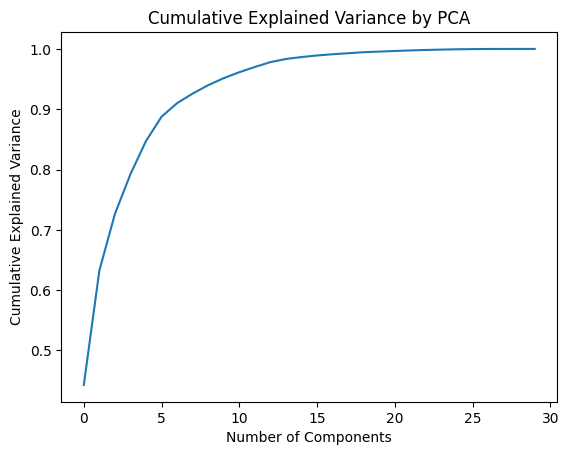

In [5]:
# Plot cumulative variance
plt.figure()
plt.plot(np.cumsum(explained_variance))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance by PCA')
plt.show()

## 6. Reduce to 2 Components

In [7]:
# Reduce to 2 principal components
pca_2 = PCA(n_components=2)
X_reduced = pca_2.fit_transform(X_scaled)

# the first two principal components together explain 63.24% of the total variance.
print('Variance explained by 2 components:', sum(pca_2.explained_variance_ratio_))

Variance explained by 2 components: 0.6324320765155944


## 7. Visualization

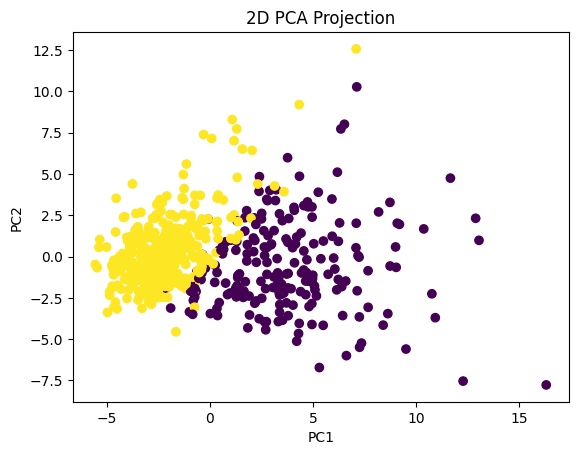

In [8]:
# Visualize in 2D
plt.figure()
plt.scatter(X_reduced[:,0], X_reduced[:,1], c=y)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('2D PCA Projection')
plt.show()

## 8. Classification Comparison

In [9]:
# Original data classification
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
model_original = LogisticRegression(max_iter=500) # Default is often 100.
model_original.fit(X_train, y_train)
y_pred_original = model_original.predict(X_test)
print('Accuracy (Original):', accuracy_score(y_test, y_pred_original))

Accuracy (Original): 0.9736842105263158


In [10]:
# PCA-reduced data classification
X_train_pca, X_test_pca, y_train, y_test = train_test_split(X_reduced, y, test_size=0.2, random_state=42)
model_pca = LogisticRegression(max_iter=500)
model_pca.fit(X_train_pca, y_train)
y_pred_pca = model_pca.predict(X_test_pca)
print('Accuracy (After PCA):', accuracy_score(y_test, y_pred_pca))

Accuracy (After PCA): 0.9912280701754386


## 9. Conclusion
PCA reduces dimensionality while preserving variance. It improves computational efficiency and allows visualization while maintaining competitive accuracy.